In [3]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
dataframe = pd.read_csv('Eartquakes-1990-2023.csv')

In [9]:
dataframe.head()

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


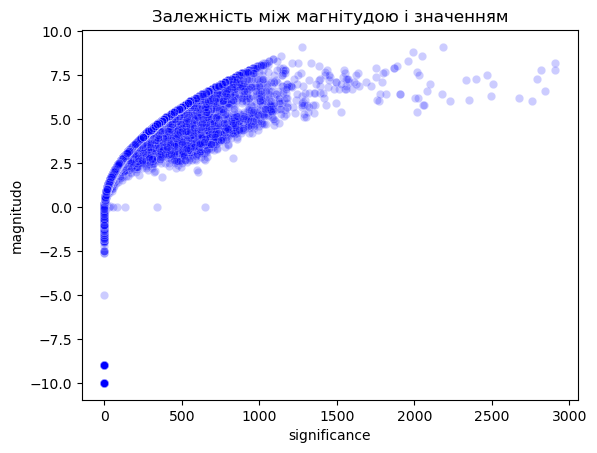

In [11]:
sns.scatterplot(x='significance', y='magnitudo', data=dataframe, alpha=0.2, color='blue')
plt.title('Залежність між магнітудою і значенням')
plt.show()

In [13]:
dataframe.corr()

ValueError: could not convert string to float: '12 km NNW of Meadow Lakes, Alaska'

In [15]:
dataframe = dataframe.drop(columns = ['place' , 'status' , 'data_type' , 'state' , 'date' , 'time' , 'tsunami'])

array([[<Axes: title={'center': 'magnitudo'}>]], dtype=object)

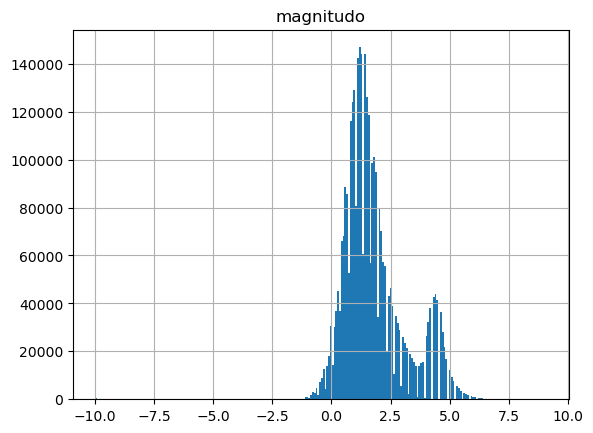

In [17]:
dataframe.hist('magnitudo',bins = 250)

In [19]:
dataframe = dataframe[dataframe['magnitudo'] > 0]

In [21]:
dataframe.head()

,significance,magnitudo,longitude,latitude,depth
0,96,2.50,-149.669200,61.730200,30.100
1,31,1.41,-155.212333,19.317667,6.585
2,19,1.11,-122.806167,38.821000,3.220
3,15,0.98,-118.846333,37.664333,-0.584
4,134,2.95,-118.934000,34.546000,16.122


In [23]:
dataframe.corr()

,significance,magnitudo,longitude,latitude,depth
significance,1.000000,0.957201,0.662790,-0.563783,0.364488
magnitudo,0.957201,1.000000,0.622885,-0.516398,0.366871
longitude,0.662790,0.622885,1.000000,-0.455191,0.167298
latitude,-0.563783,-0.516398,-0.455191,1.000000,-0.231962
depth,0.364488,0.366871,0.167298,-0.231962,1.000000


In [25]:
dataframe.describe()

,significance,magnitudo,longitude,latitude,depth
count,3.333939e+06,3.333939e+06,3.333939e+06,3.333939e+06,3.333939e+06
mean,7.649146e+01,1.844484e+00,-1.010301e+02,3.736931e+01,2.321515e+01
std,1.024033e+02,1.244765e+00,7.728899e+01,2.056294e+01,5.533029e+01
min,0.000000e+00,1.000000e-02,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.500000e+01,1.000000e+00,-1.465836e+02,3.401873e+01,3.156000e+00
50%,3.500000e+01,1.500000e+00,-1.189680e+02,3.787283e+01,7.800000e+00
75%,8.100000e+01,2.300000e+00,-1.158150e+02,4.808533e+01,1.670000e+01
max,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02


In [27]:
magnitude_data = dataframe['magnitudo'].values.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(magnitude_data)

cluster_centers = kmeans.cluster_centers_

print("Cluster Centers:", cluster_centers)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Cluster Centers: [[1.30871933]
 [3.95505719]]


In [29]:
threshold_1 = 1.30871933  # Lower threshold
threshold_2 = 3.95505719  # Upper threshold

In [31]:
def classify_magnitude(magnitude):
    if magnitude <= threshold_1:
        return 0  # Class 0
    elif magnitude > threshold_2:
        return 2  # Class 2
    else:
        return 1  # Class 1

In [33]:
dataframe['magnitude_class'] = dataframe['magnitudo'].apply(classify_magnitude)

X = dataframe[['significance', 'longitude', 'latitude', 'depth']]
y = dataframe['magnitude_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
classifier = RandomForestClassifier(random_state=42)

classifier.fit(X_train_scaled, y_train)

y_pred = classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.9969135617317648
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00    279787
           1       1.00      0.99      1.00    310109
           2       1.00      1.00      1.00     76892

    accuracy                           1.00    666788
   macro avg       1.00      1.00      1.00    666788
weighted avg       1.00      1.00      1.00    666788

Confusion Matrix:
 [[279345    442      0]
 [  1451 308552    106]
 [     0     59  76833]]


In [16]:
class_0 = dataframe[dataframe['magnitude_class'] == 0]
class_1 = dataframe[dataframe['magnitude_class'] == 1]
class_2 = dataframe[dataframe['magnitude_class'] == 2]

X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(class_0[['significance', 'longitude', 'latitude']], class_0['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_1, X_test_reg_1, y_train_reg_1, y_test_reg_1 = train_test_split(class_1[['significance', 'longitude', 'latitude']], class_1['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_2, X_test_reg_2, y_train_reg_2, y_test_reg_2 = train_test_split(class_2[['significance', 'longitude', 'latitude']], class_2['magnitudo'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)
X_train_scaled_reg_1 = scaler_reg.fit_transform(X_train_reg_1)
X_test_scaled_reg_1 = scaler_reg.transform(X_test_reg_1)
X_train_scaled_reg_2 = scaler_reg.fit_transform(X_train_reg_2)
X_test_scaled_reg_2 = scaler_reg.transform(X_test_reg_2)

# Add in diff models
regression_model_0 = ExtraTreesRegressor(n_estimators=5, random_state=42)
regression_model_1 = ExtraTreesRegressor(n_estimators=5, random_state=42)
regression_model_2 = ExtraTreesRegressor(n_estimators=5, random_state=42)

regression_model_0.fit(X_train_scaled_reg_0, y_train_reg_0)
regression_model_1.fit(X_train_scaled_reg_1, y_train_reg_1)
regression_model_2.fit(X_train_scaled_reg_2, y_train_reg_2)

y_pred_reg_0 = regression_model_0.predict(X_test_scaled_reg_0)
y_pred_reg_1 = regression_model_1.predict(X_test_scaled_reg_1)
y_pred_reg_2 = regression_model_2.predict(X_test_scaled_reg_2)

In [17]:
reg_0_mae = mean_absolute_error(y_test_reg_0, y_pred_reg_0)
reg_1_mae = mean_absolute_error(y_test_reg_1, y_pred_reg_1)
reg_2_mae = mean_absolute_error(y_test_reg_2, y_pred_reg_2)

reg_0_mse = mean_squared_error(y_test_reg_0, y_pred_reg_0)
reg_1_mse = mean_squared_error(y_test_reg_1, y_pred_reg_1)
reg_2_mse = mean_squared_error(y_test_reg_2, y_pred_reg_2)

reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)
reg_1_r2 = r2_score(y_test_reg_1, y_pred_reg_1)
reg_2_r2 = r2_score(y_test_reg_2, y_pred_reg_2)

print("Regression Model 0 - MAE:", reg_0_mae)
print("Regression Model 1 - MAE:", reg_1_mae)
print("Regression Model 2 - MAE:", reg_2_mae)

print("Regression Model 0 - MSE:", reg_0_mse)
print("Regression Model 1 - MSE:", reg_1_mse)
print("Regression Model 2 - MSE:", reg_2_mse)

print("Regression Model 0 - R^2 Score:", reg_0_r2)
print("Regression Model 1 - R^2 Score:", reg_1_r2)
print("Regression Model 2 - R^2 Score:", reg_2_r2)

Regression Model 0 - MAE: 0.010314944804148143
Regression Model 1 - MAE: 0.0035733970650783393
Regression Model 2 - MAE: 0.004132684197869536
Regression Model 0 - MSE: 0.0003668710643480428
Regression Model 1 - MSE: 0.00039004841988212537
Regression Model 2 - MSE: 0.0020079195371921314
Regression Model 0 - R^2 Score: 0.9966555556089464
Regression Model 1 - R^2 Score: 0.9990322962913728
Regression Model 2 - R^2 Score: 0.9894091695470147


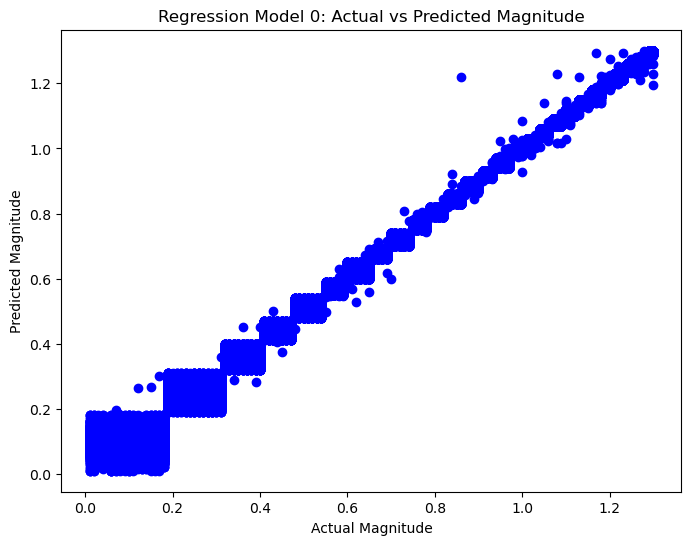

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

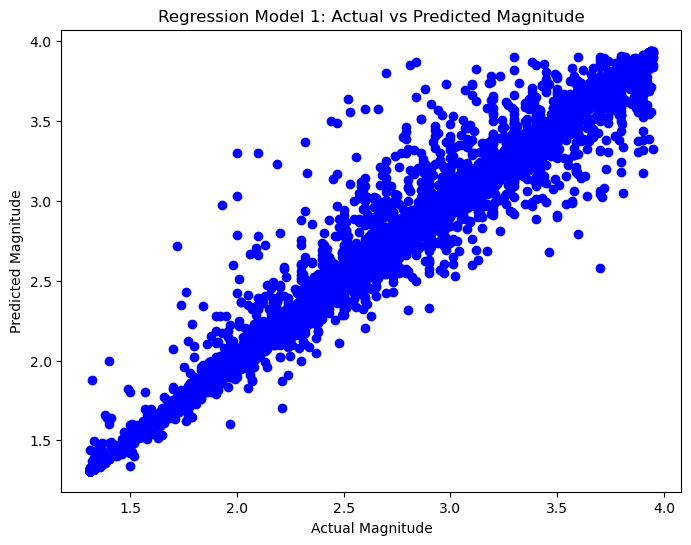

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_1, y_pred_reg_1, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 1: Actual vs Predicted Magnitude')
plt.show()

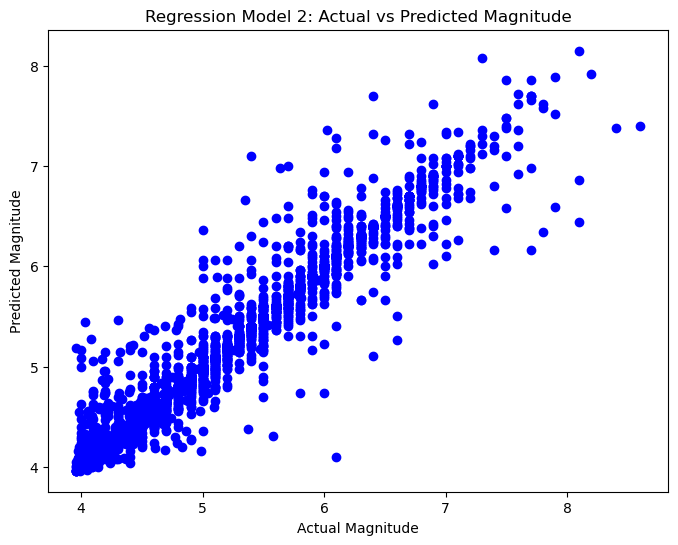

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_2, y_pred_reg_2, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 2: Actual vs Predicted Magnitude')
plt.show()

DECISION TREE REGRESSOR

In [22]:
class_0 = dataframe[dataframe['magnitude_class'] == 0]
class_1 = dataframe[dataframe['magnitude_class'] == 1]
class_2 = dataframe[dataframe['magnitude_class'] == 2]

X_train_reg_0, X_test_reg_0, y_train_reg_0, y_test_reg_0 = train_test_split(class_0[['significance', 'longitude', 'latitude']], class_0['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_1, X_test_reg_1, y_train_reg_1, y_test_reg_1 = train_test_split(class_1[['significance', 'longitude', 'latitude']], class_1['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_2, X_test_reg_2, y_train_reg_2, y_test_reg_2 = train_test_split(class_2[['significance', 'longitude', 'latitude']], class_2['magnitudo'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_0 = scaler_reg.fit_transform(X_train_reg_0)
X_test_scaled_reg_0 = scaler_reg.transform(X_test_reg_0)
X_train_scaled_reg_1 = scaler_reg.fit_transform(X_train_reg_1)
X_test_scaled_reg_1 = scaler_reg.transform(X_test_reg_1)
X_train_scaled_reg_2 = scaler_reg.fit_transform(X_train_reg_2)
X_test_scaled_reg_2 = scaler_reg.transform(X_test_reg_2)

# Add in diff models
regression_dt_0 = DecisionTreeRegressor( random_state=42)
regression_dt_1 = DecisionTreeRegressor( random_state=42)
regression_dt_2 = DecisionTreeRegressor( random_state=42)

regression_dt_0.fit(X_train_scaled_reg_0, y_train_reg_0)
regression_dt_1.fit(X_train_scaled_reg_1, y_train_reg_1)
regression_dt_2.fit(X_train_scaled_reg_2, y_train_reg_2)

y_pred_reg_0 = regression_dt_0.predict(X_test_scaled_reg_0)
y_pred_reg_1 = regression_dt_1.predict(X_test_scaled_reg_1)
y_pred_reg_2 = regression_dt_2.predict(X_test_scaled_reg_2)

In [23]:
reg_0_mae = mean_absolute_error(y_test_reg_0, y_pred_reg_0)
reg_1_mae = mean_absolute_error(y_test_reg_1, y_pred_reg_1)
reg_2_mae = mean_absolute_error(y_test_reg_2, y_pred_reg_2)

reg_0_mse = mean_squared_error(y_test_reg_0, y_pred_reg_0)
reg_1_mse = mean_squared_error(y_test_reg_1, y_pred_reg_1)
reg_2_mse = mean_squared_error(y_test_reg_2, y_pred_reg_2)

reg_0_r2 = r2_score(y_test_reg_0, y_pred_reg_0)
reg_1_r2 = r2_score(y_test_reg_1, y_pred_reg_1)
reg_2_r2 = r2_score(y_test_reg_2, y_pred_reg_2)

print("Regression Model 0 - MAE:", reg_0_mae)
print("Regression Model 1 - MAE:", reg_1_mae)
print("Regression Model 2 - MAE:", reg_2_mae)

print("Regression Model 0 - MSE:", reg_0_mse)
print("Regression Model 1 - MSE:", reg_1_mse)
print("Regression Model 2 - MSE:", reg_2_mse)

print("Regression Model 0 - R^2 Score:", reg_0_r2)
print("Regression Model 1 - R^2 Score:", reg_1_r2)
print("Regression Model 2 - R^2 Score:", reg_2_r2)

Regression Model 0 - MAE: 0.011435606182757387
Regression Model 1 - MAE: 0.003782734193884904
Regression Model 2 - MAE: 0.004396564257526591
Regression Model 0 - MSE: 0.0005101606125063783
Regression Model 1 - MSE: 0.0005920376425285223
Regression Model 2 - MSE: 0.002792970602763715
Regression Model 0 - R^2 Score: 0.9953493094309156
Regression Model 1 - R^2 Score: 0.9985311643551974
Regression Model 2 - R^2 Score: 0.9852683946910509


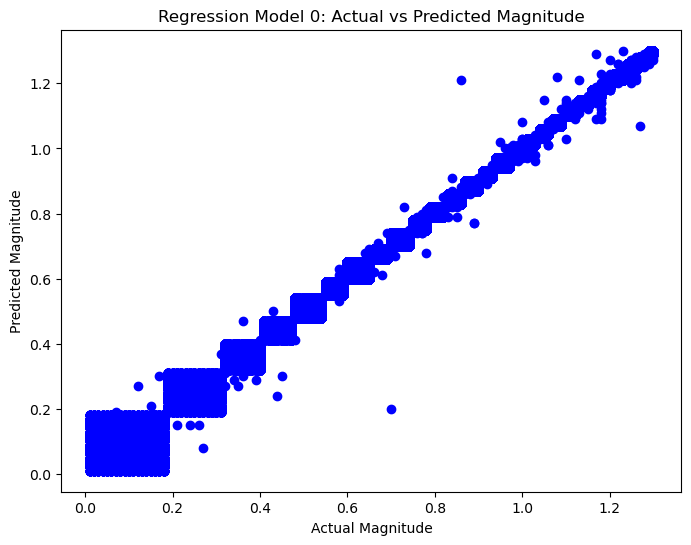

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_0, y_pred_reg_0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()


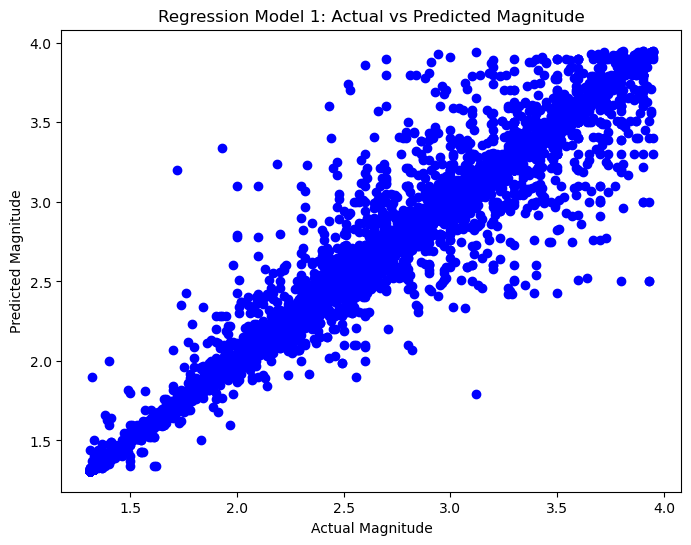

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_1, y_pred_reg_1, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 1: Actual vs Predicted Magnitude')
plt.show()

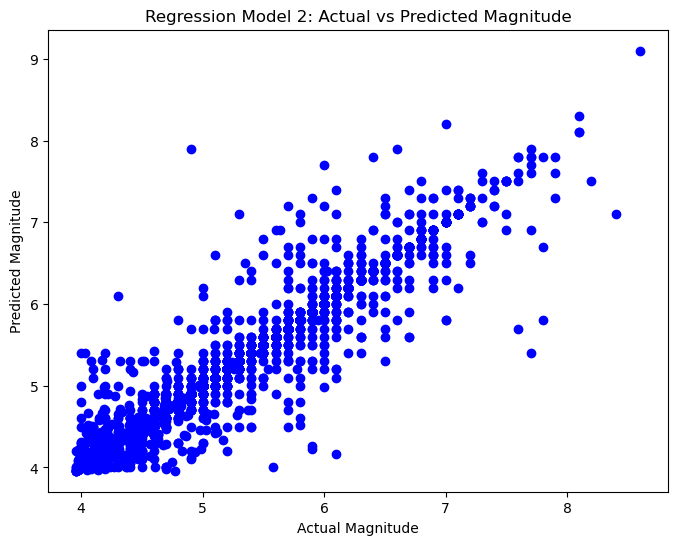

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_2, y_pred_reg_2, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 2: Actual vs Predicted Magnitude')
plt.show()


In [27]:
dataframe[(dataframe['magnitudo'] > 6.0) & (dataframe['magnitudo'] < 8.0)]

,significance,magnitudo,longitude,latitude,depth,magnitude_class
451,650,6.5,-172.8500,-15.3970,53.500,2
1240,611,6.3,95.2410,24.7530,119.200,2
1972,572,6.1,-177.4670,-29.7090,58.300,2
3197,591,6.2,96.1000,3.8850,45.700,2
5146,611,6.3,71.2500,37.0470,109.900,2
...,...,...,...,...,...,...
3440597,637,6.3,-93.8771,15.0337,35.000,2
3441336,896,7.2,-160.7604,54.4596,32.571,2
3441774,900,6.6,-70.4688,-38.1951,186.000,2
3442480,784,6.5,-88.1265,12.8140,69.727,2


In [28]:
input_df = pd.DataFrame({
    'significance': [650],
    'longitude': [-172.8500],
    'latitude': [-15.3970]
})

input_features = scaler_reg.transform(input_df)

input_class = classifier.predict(input_features)[0]

print(f'Magnitude Class is {input_class}')

if input_class == 0:
    predicted_magnitude = regression_dt_0.predict(input_features)
elif input_class == 1:
    predicted_magnitude = regression_dt_1.predict(input_features)
else:
    predicted_magnitude = regression_dt_2.predict(input_features)

print("Predicted Magnitude:", predicted_magnitude[0])

Magnitude Class is 2
Predicted Magnitude: 6.5


Random Forest Regressor

In [30]:
class_0 = dataframe[dataframe['magnitude_class'] == 0]
class_1 = dataframe[dataframe['magnitude_class'] == 1]
class_2 = dataframe[dataframe['magnitude_class'] == 2]

X_train_reg_rf0, X_test_reg_rf0, y_train_reg_rf0, y_test_reg_rf0 = train_test_split(class_0[['significance', 'longitude', 'latitude']], class_0['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_rf1, X_test_reg_rf1, y_train_reg_rf1, y_test_reg_rf1 = train_test_split(class_1[['significance', 'longitude', 'latitude']], class_1['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_rf2, X_test_reg_rf2, y_train_reg_rf2, y_test_reg_rf2 = train_test_split(class_2[['significance', 'longitude', 'latitude']], class_2['magnitudo'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_rf0 = scaler_reg.fit_transform(X_train_reg_rf0)
X_test_scaled_reg_rf0 = scaler_reg.transform(X_test_reg_rf0)
X_train_scaled_reg_rf1 = scaler_reg.fit_transform(X_train_reg_rf1)
X_test_scaled_reg_rf1 = scaler_reg.transform(X_test_reg_rf1)
X_train_scaled_reg_rf2 = scaler_reg.fit_transform(X_train_reg_rf2)
X_test_scaled_reg_rf2 = scaler_reg.transform(X_test_reg_rf2)

# Add in diff models
regression_model_rf0 = RandomForestRegressor(n_estimators=5, random_state=42)
regression_model_rf1 = RandomForestRegressor(n_estimators=5, random_state=42)
regression_model_rf2 = RandomForestRegressor(n_estimators=5, random_state=42)

regression_model_rf0.fit(X_train_scaled_reg_rf0, y_train_reg_rf0)
regression_model_rf1.fit(X_train_scaled_reg_rf1, y_train_reg_rf1)
regression_model_rf2.fit(X_train_scaled_reg_rf2, y_train_reg_rf2)

y_pred_reg_rf0 = regression_model_rf0.predict(X_test_scaled_reg_rf0)
y_pred_reg_rf1 = regression_model_rf1.predict(X_test_scaled_reg_rf1)
y_pred_reg_rf2 = regression_model_rf2.predict(X_test_scaled_reg_rf2)

In [31]:
reg_0_mae_rf = mean_absolute_error(y_test_reg_rf0, y_pred_reg_rf0)
reg_1_mae_rf = mean_absolute_error(y_test_reg_rf1, y_pred_reg_rf1)
reg_2_mae_rf = mean_absolute_error(y_test_reg_rf2, y_pred_reg_rf2)

reg_0_mse_rf = mean_squared_error(y_test_reg_rf0, y_pred_reg_rf0)
reg_1_mse_rf = mean_squared_error(y_test_reg_rf1, y_pred_reg_rf1)
reg_2_mse_rf = mean_squared_error(y_test_reg_rf2, y_pred_reg_rf2)

reg_0_r2_rf = r2_score(y_test_reg_rf0, y_pred_reg_rf0)
reg_1_r2_rf = r2_score(y_test_reg_rf1, y_pred_reg_rf1)
reg_2_r2_rf = r2_score(y_test_reg_rf2, y_pred_reg_rf2)

print("Regression Model 0 - MAE:", reg_0_mae_rf)
print("Regression Model 1 - MAE:", reg_1_mae_rf)
print("Regression Model 2 - MAE:", reg_2_mae_rf)

print("Regression Model 0 - MSE:", reg_0_mse_rf)
print("Regression Model 1 - MSE:", reg_1_mse_rf)
print("Regression Model 2 - MSE:", reg_2_mse_rf)

print("Regression Model 0 - R^2 Score:", reg_0_r2_rf)
print("Regression Model 1 - R^2 Score:", reg_1_r2_rf)
print("Regression Model 2 - R^2 Score:", reg_2_r2_rf)

Regression Model 0 - MAE: 0.010185430526851783
Regression Model 1 - MAE: 0.003639898517491792
Regression Model 2 - MAE: 0.003986234451708247
Regression Model 0 - MSE: 0.0003508501598432952
Regression Model 1 - MSE: 0.0004151962288226558
Regression Model 2 - MSE: 0.0017782135114843022
Regression Model 0 - R^2 Score: 0.996801604260414
Regression Model 1 - R^2 Score: 0.9989699049913825
Regression Model 2 - R^2 Score: 0.9906207607125167


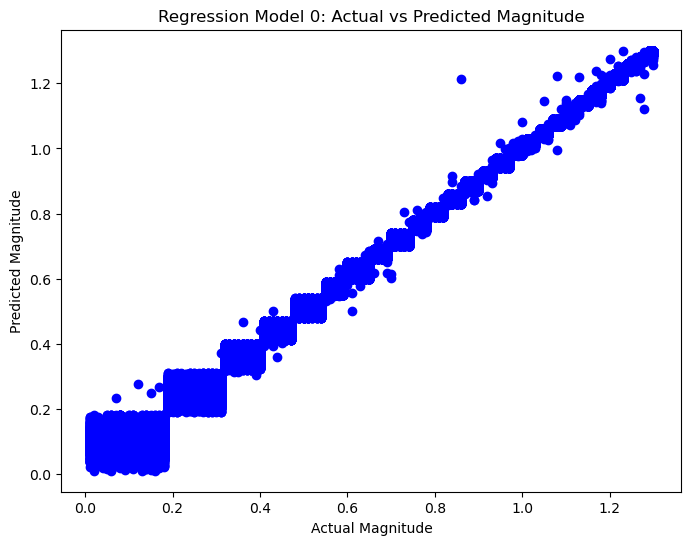

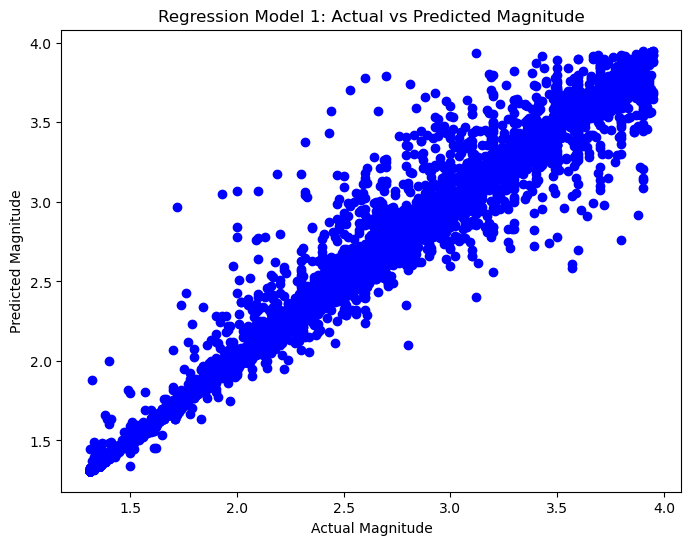

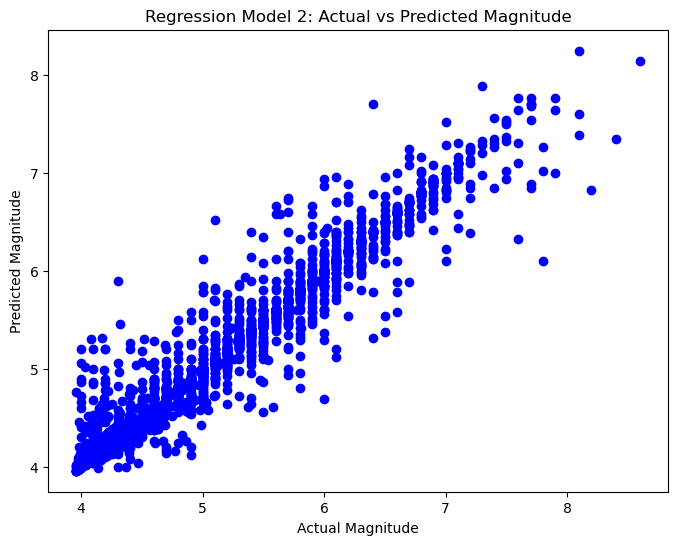

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_rf0, y_pred_reg_rf0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_rf1, y_pred_reg_rf1, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 1: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_rf2, y_pred_reg_rf2, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 2: Actual vs Predicted Magnitude')
plt.show()

In [33]:
dataframe[(dataframe['magnitudo'] > 6.0) & (dataframe['magnitudo'] < 8.0)]


,significance,magnitudo,longitude,latitude,depth,magnitude_class
451,650,6.5,-172.8500,-15.3970,53.500,2
1240,611,6.3,95.2410,24.7530,119.200,2
1972,572,6.1,-177.4670,-29.7090,58.300,2
3197,591,6.2,96.1000,3.8850,45.700,2
5146,611,6.3,71.2500,37.0470,109.900,2
...,...,...,...,...,...,...
3440597,637,6.3,-93.8771,15.0337,35.000,2
3441336,896,7.2,-160.7604,54.4596,32.571,2
3441774,900,6.6,-70.4688,-38.1951,186.000,2
3442480,784,6.5,-88.1265,12.8140,69.727,2


In [34]:
input_df = pd.DataFrame({
    'significance': [637],
    'longitude': [-93.8771],
    'latitude': [15.0337]
})

input_features = scaler_reg.transform(input_df)

input_class = classifier.predict(input_features)[0]

print(f'Magnitude Class is {input_class}')

if input_class == 0:
    predicted_magnitude = regression_model_rf0.predict(input_features)
elif input_class == 1:
    predicted_magnitude = regression_model_rf1.predict(input_features)
else:
    predicted_magnitude = regression_model_rf2.predict(input_features)

print("Predicted Magnitude:", predicted_magnitude[0])

Magnitude Class is 2
Predicted Magnitude: 6.24


Decision Tree Regressor

In [36]:
class_0 = dataframe[dataframe['magnitude_class'] == 0]
class_1 = dataframe[dataframe['magnitude_class'] == 1]
class_2 = dataframe[dataframe['magnitude_class'] == 2]

X_train_reg_dt0, X_test_reg_dt0, y_train_reg_dt0, y_test_reg_dt0 = train_test_split(class_0[['significance', 'longitude', 'latitude']], class_0['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_dt1, X_test_reg_dt1, y_train_reg_dt1, y_test_reg_dt1 = train_test_split(class_1[['significance', 'longitude', 'latitude']], class_1['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_dt2, X_test_reg_dt2, y_train_reg_dt2, y_test_reg_dt2 = train_test_split(class_2[['significance', 'longitude', 'latitude']], class_2['magnitudo'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_dt0 = scaler_reg.fit_transform(X_train_reg_dt0)
X_test_scaled_reg_dt0 = scaler_reg.transform(X_test_reg_dt0)
X_train_scaled_reg_dt1 = scaler_reg.fit_transform(X_train_reg_dt1)
X_test_scaled_reg_dt1 = scaler_reg.transform(X_test_reg_dt1)
X_train_scaled_reg_dt2 = scaler_reg.fit_transform(X_train_reg_dt2)
X_test_scaled_reg_dt2 = scaler_reg.transform(X_test_reg_dt2)

# Add in diff models
regression_model_dt0 = DecisionTreeRegressor( random_state=42)
regression_model_dt1 = DecisionTreeRegressor( random_state=42)
regression_model_dt2 = DecisionTreeRegressor( random_state=42)

regression_model_dt0.fit(X_train_scaled_reg_dt0, y_train_reg_dt0)
regression_model_dt1.fit(X_train_scaled_reg_dt1, y_train_reg_dt1)
regression_model_dt2.fit(X_train_scaled_reg_dt2, y_train_reg_dt2)

y_pred_reg_dt0 = regression_model_dt0.predict(X_test_scaled_reg_dt0)
y_pred_reg_dt1 = regression_model_dt1.predict(X_test_scaled_reg_dt1)
y_pred_reg_dt2 = regression_model_dt2.predict(X_test_scaled_reg_dt2)


In [37]:
reg_0_mae_dt = mean_absolute_error(y_test_reg_dt0, y_pred_reg_dt0)
reg_1_mae_dt = mean_absolute_error(y_test_reg_dt1, y_pred_reg_dt1)
reg_2_mae_dt = mean_absolute_error(y_test_reg_dt2, y_pred_reg_dt2)

reg_0_mse_dt = mean_squared_error(y_test_reg_dt0, y_pred_reg_dt0)
reg_1_mse_dt = mean_squared_error(y_test_reg_dt1, y_pred_reg_dt1)
reg_2_mse_dt = mean_squared_error(y_test_reg_dt2, y_pred_reg_dt2)

reg_0_r2_dt = r2_score(y_test_reg_dt0, y_pred_reg_dt0)
reg_1_r2_dt = r2_score(y_test_reg_dt1, y_pred_reg_dt1)
reg_2_r2_dt = r2_score(y_test_reg_dt2, y_pred_reg_dt2)

print("Regression Model 0 - MAE:", reg_0_mae_dt)
print("Regression Model 1 - MAE:", reg_1_mae_dt)
print("Regression Model 2 - MAE:", reg_2_mae_dt)

print("Regression Model 0 - MSE:", reg_0_mse_dt)
print("Regression Model 1 - MSE:", reg_1_mse_dt)
print("Regression Model 2 - MSE:", reg_2_mse_dt)

print("Regression Model 0 - R^2 Score:", reg_0_r2_dt)
print("Regression Model 1 - R^2 Score:", reg_1_r2_dt)
print("Regression Model 2 - R^2 Score:", reg_2_r2_dt)

Regression Model 0 - MAE: 0.011435606182757387
Regression Model 1 - MAE: 0.003782734193884904
Regression Model 2 - MAE: 0.004396564257526591
Regression Model 0 - MSE: 0.0005101606125063783
Regression Model 1 - MSE: 0.0005920376425285223
Regression Model 2 - MSE: 0.002792970602763715
Regression Model 0 - R^2 Score: 0.9953493094309156
Regression Model 1 - R^2 Score: 0.9985311643551974
Regression Model 2 - R^2 Score: 0.9852683946910509


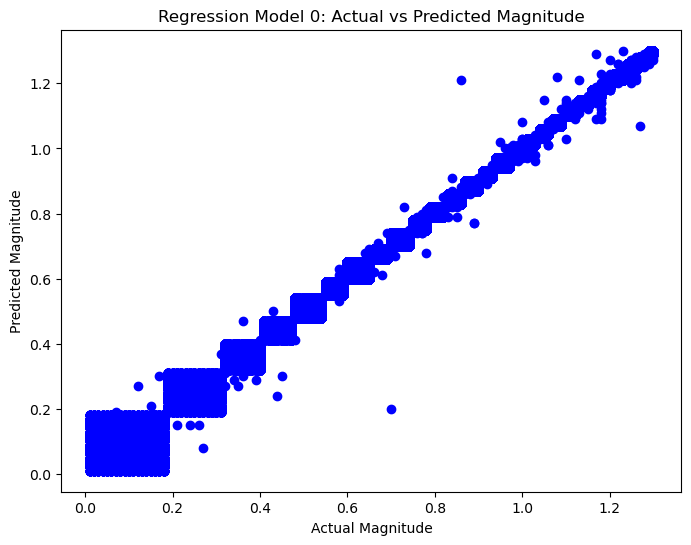

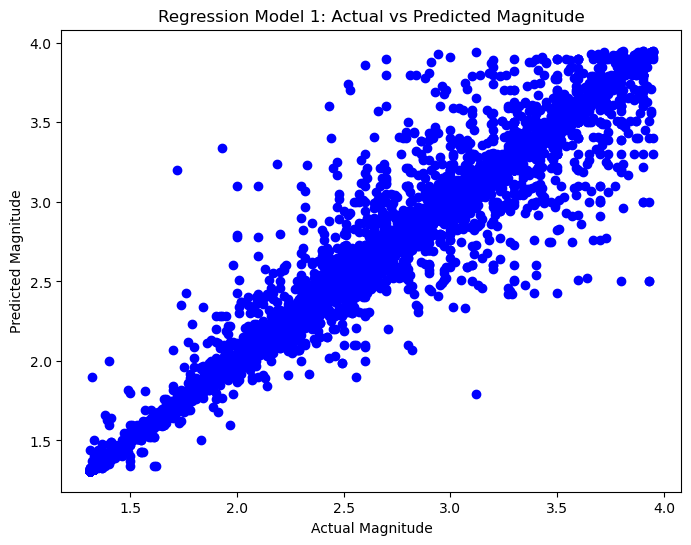

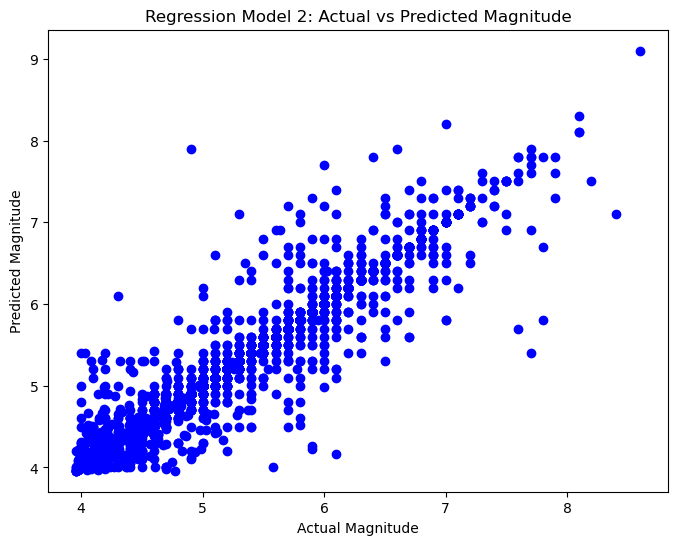

In [38]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_dt0, y_pred_reg_dt0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_dt1, y_pred_reg_dt1, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 1: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_dt2, y_pred_reg_dt2, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 2: Actual vs Predicted Magnitude')
plt.show()

ADA BOOST

In [75]:
class_0 = dataframe[dataframe['magnitude_class'] == 0]
class_1 = dataframe[dataframe['magnitude_class'] == 1]
class_2 = dataframe[dataframe['magnitude_class'] == 2]

X_train_reg_ad0, X_test_reg_ad0, y_train_reg_ad0, y_test_reg_ad0 = train_test_split(class_0[['significance', 'longitude', 'latitude']], class_0['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_ad1, X_test_reg_ad1, y_train_reg_ad1, y_test_reg_ad1 = train_test_split(class_1[['significance', 'longitude', 'latitude']], class_1['magnitudo'], test_size=0.2, random_state=42)
X_train_reg_ad2, X_test_reg_ad2, y_train_reg_ad2, y_test_reg_ad2 = train_test_split(class_2[['significance', 'longitude', 'latitude']], class_2['magnitudo'], test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled_reg_ad0 = scaler_reg.fit_transform(X_train_reg_ad0)
X_test_scaled_reg_ad0 = scaler_reg.transform(X_test_reg_ad0)
X_train_scaled_reg_ad1 = scaler_reg.fit_transform(X_train_reg_ad1)
X_test_scaled_reg_ad1 = scaler_reg.transform(X_test_reg_ad1)
X_train_scaled_reg_ad2 = scaler_reg.fit_transform(X_train_reg_ad2)
X_test_scaled_reg_ad2 = scaler_reg.transform(X_test_reg_ad2)

# Add in diff models
regression_model_ad0 = AdaBoostRegressor(n_estimators=50, random_state=42)
regression_model_ad1 = AdaBoostRegressor(n_estimators=50, random_state=42)
regression_model_ad2 = AdaBoostRegressor(n_estimators=50, random_state=42)

regression_model_ad0.fit(X_train_scaled_reg_ad0, y_train_reg_ad0)
regression_model_ad1.fit(X_train_scaled_reg_ad1, y_train_reg_ad1)
regression_model_ad2.fit(X_train_scaled_reg_ad2, y_train_reg_ad2)

y_pred_reg_ad0 = regression_model_ad0.predict(X_test_scaled_reg_ad0)
y_pred_reg_ad1 = regression_model_ad1.predict(X_test_scaled_reg_ad1)
y_pred_reg_ad2 = regression_model_ad2.predict(X_test_scaled_reg_ad2)

In [77]:
reg_0_mae_ad = mean_absolute_error(y_test_reg_ad0, y_pred_reg_ad0)
reg_1_mae_ad = mean_absolute_error(y_test_reg_ad1, y_pred_reg_ad1)
reg_2_mae_ad = mean_absolute_error(y_test_reg_ad2, y_pred_reg_ad2)

reg_0_mse_ad = mean_squared_error(y_test_reg_ad0, y_pred_reg_ad0)
reg_1_mse_ad = mean_squared_error(y_test_reg_ad1, y_pred_reg_ad1)
reg_2_mse_ad = mean_squared_error(y_test_reg_ad2, y_pred_reg_ad2)

reg_0_r2_ad = r2_score(y_test_reg_ad0, y_pred_reg_ad0)
reg_1_r2_ad = r2_score(y_test_reg_ad1, y_pred_reg_ad1)
reg_2_r2_ad = r2_score(y_test_reg_ad2, y_pred_reg_ad2)

print("Regression Model 0 - MAE:", reg_0_mae_ad)
print("Regression Model 1 - MAE:", reg_1_mae_ad)
print("Regression Model 2 - MAE:", reg_2_mae_ad)

print("Regression Model 0 - MSE:", reg_0_mse_ad)
print("Regression Model 1 - MSE:", reg_1_mse_ad)
print("Regression Model 2 - MSE:", reg_2_mse_ad)

print("Regression Model 0 - R^2 Score:", reg_0_r2_ad)
print("Regression Model 1 - R^2 Score:", reg_1_r2_ad)
print("Regression Model 2 - R^2 Score:", reg_2_r2_ad)

Regression Model 0 - MAE: 0.04475845659518218
Regression Model 1 - MAE: 0.07879677190034928
Regression Model 2 - MAE: 0.07314022193333573
Regression Model 0 - MSE: 0.0031271394883314297
Regression Model 1 - MSE: 0.0123338411236173
Regression Model 2 - MSE: 0.01618482135842234
Regression Model 0 - R^2 Score: 0.9714925892550893
Regression Model 1 - R^2 Score: 0.9693999432158943
Regression Model 2 - R^2 Score: 0.9146326853522204


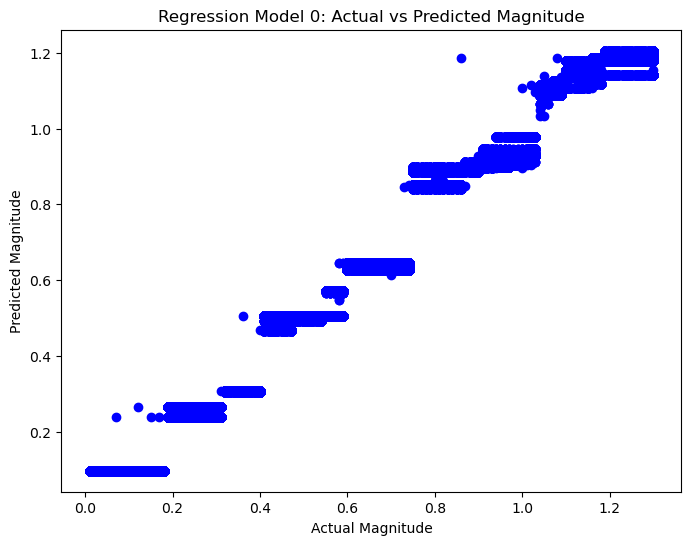

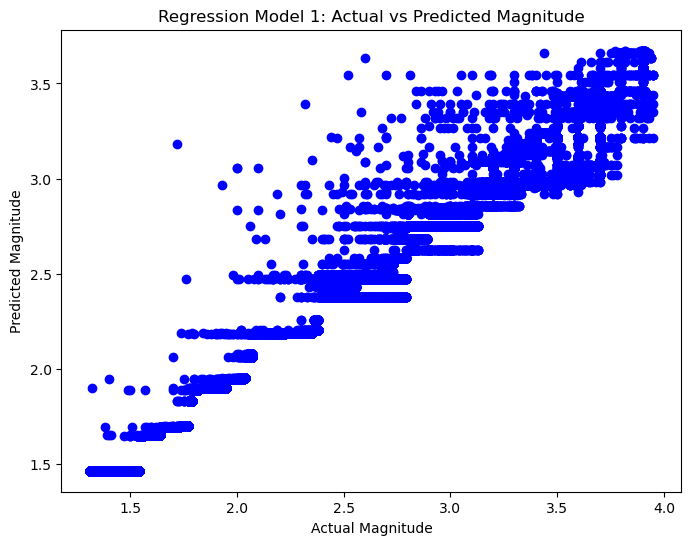

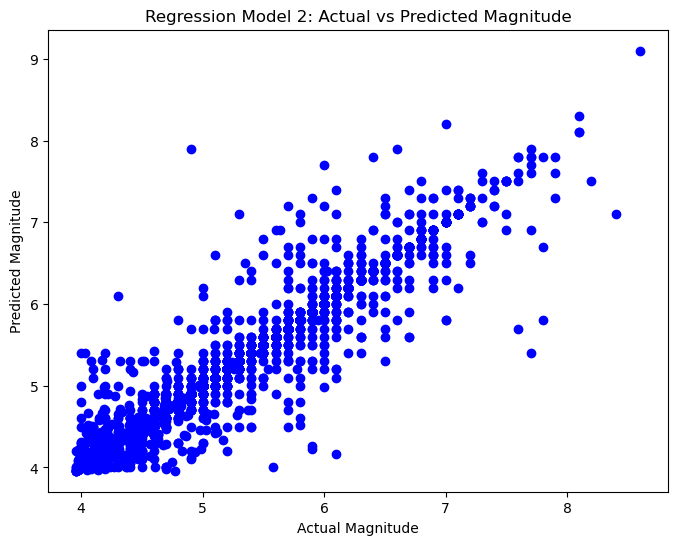

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_ad0, y_pred_reg_ad0, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 0: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_ad1, y_pred_reg_ad1, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 1: Actual vs Predicted Magnitude')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg_dt2, y_pred_reg_dt2, color='blue')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Regression Model 2: Actual vs Predicted Magnitude')
plt.show()

In [81]:
input_df = pd.DataFrame({
    'significance': [637],
    'longitude': [-93.8771],
    'latitude': [15.0337]
})

input_features = scaler_reg.transform(input_df)

input_class = classifier.predict(input_features)[0]

print(f'Magnitude Class is {input_class}')

if input_class == 0:
    predicted_magnitude = regression_model_ad0.predict(input_features)
elif input_class == 1:
    predicted_magnitude = regression_model_ad1.predict(input_features)
else:
    predicted_magnitude = regression_model_ad2.predict(input_features)

print("Predicted Magnitude:", predicted_magnitude[0])

Magnitude Class is 2
Predicted Magnitude: 5.65122143191643
